# Notebook 16: Multi-Year Static Art Exploration

**One Sensor, One Year → One Grid, Many Years**

Can we make a static poster that captures the *arc* — India's grid growing, transforming, breathing over a decade+? 

Data sources:
- **POSOCO**: Demand met, energy met, peak shortage — 2013 to 2026 (~13 years)
- **CEA**: Daily generation by fuel — 2018 to 2026 (~8 years, coal from 2018, full mix from ~2020)
- **Derived**: CO2 estimates from fuel mix (we'll compute for multi-year)

Questions:
1. Do stacked year strips work, or is it too busy?
2. Can we layer CO2 without clutter?
3. What static form makes you *feel* the transformation?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
import warnings
warnings.filterwarnings('ignore')

# ── Load POSOCO (demand/supply, 2013–2026) ──
posoco = pd.read_csv('../data/raw/POSOCO_data.csv')
posoco['date'] = pd.to_datetime(posoco['yyyymmdd'], format='%Y%m%d')
posoco['year'] = posoco['date'].dt.year
posoco['doy'] = posoco['date'].dt.dayofyear

# ── Load CEA all years (generation by fuel, 2018–2026) ──
cea = pd.read_csv('../data/processed/india_all_years.csv', parse_dates=['date'])
cea['year'] = cea['date'].dt.year
cea['doy'] = cea['date'].dt.dayofyear

# ── CO2 emission factors (kg CO2 per MU → tonnes CO2 per GWh) ──
# Same factors used in notebook 11 for 2024
# Coal: ~1.0 tCO2/MWh, Lignite: ~1.2, Gas: ~0.45
co2_factors = {'coal': 1000, 'lignite': 1200, 'gas': 450}

cea['co2_est'] = (
    cea['coal'].fillna(0) * co2_factors['coal'] +
    cea['lignite'].fillna(0) * co2_factors['lignite'] +
    cea['gas'].fillna(0) * co2_factors['gas']
)

# Quick summary
print("=== POSOCO ===")
print(f"Date range: {posoco['date'].min().date()} to {posoco['date'].max().date()}")
print(f"Rows: {len(posoco)}")
print(f"Years: {sorted(posoco['year'].unique())}")
print()
print("=== CEA ===")
print(f"Date range: {cea['date'].min().date()} to {cea['date'].max().date()}")
print(f"Rows: {len(cea)}")
print(f"Years with coal data: {sorted(cea[cea['coal'].notna()]['year'].unique())}")
print(f"Years with total data: {sorted(cea[cea['total'].notna()]['year'].unique())}")
print()
print("=== CO2 estimate coverage ===")
for yr in sorted(cea['year'].unique()):
    sub = cea[(cea['year']==yr) & (cea['co2_est'] > 0)]
    print(f"  {yr}: {len(sub)} days with CO2 estimates")

=== POSOCO ===
Date range: 2013-01-02 to 2026-03-26
Rows: 4832
Years: [np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]

=== CEA ===
Date range: 2018-04-01 to 2026-03-25
Rows: 2916
Years with coal data: [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Years with total data: [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]

=== CO2 estimate coverage ===
  2018: 275 days with CO2 estimates
  2019: 365 days with CO2 estimates
  2020: 292 days with CO2 estimates
  2021: 364 days with CO2 estimates
  2022: 365 days with CO2 estimates
  2023: 365 days with CO2 estimates
  2024: 366 days with CO2 estimates
  2025: 365 days with CO2 estimates
  2026

---
## Form 1: Year-over-Year Demand Heatmap

Each row = one year. Each column = day of year. Color = demand met.
Simple, dense, lets you see growth + seasonality at a glance.

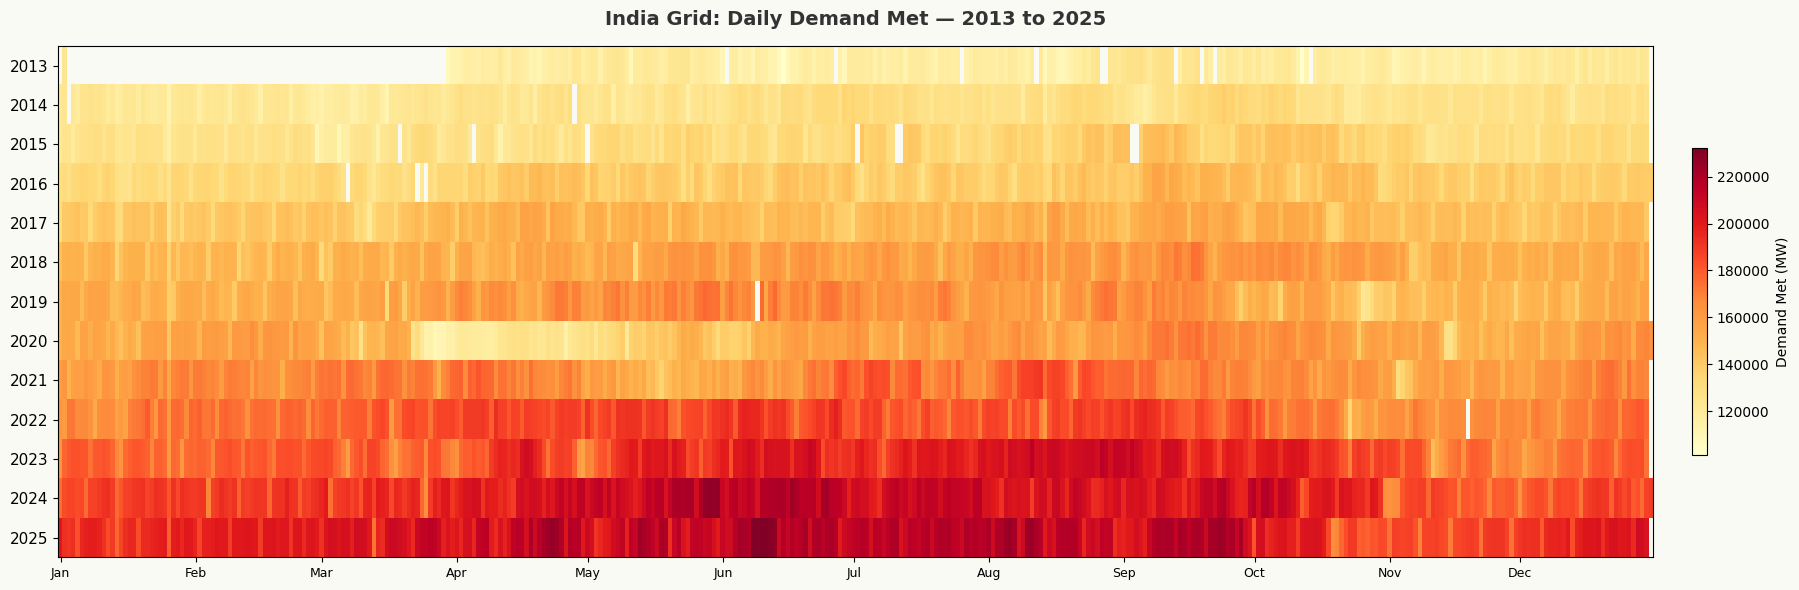

Each row is a year. Brighter = higher demand.
You can see: demand growing year over year, the summer peak getting hotter, COVID dip in 2020.


In [2]:
bg_color = '#FAFAF5'

# Build year × day-of-year matrix for DemandMet
years_posoco = list(range(2013, 2026))  # full years only
demand_matrix = np.full((len(years_posoco), 366), np.nan)

for i, yr in enumerate(years_posoco):
    sub = posoco[posoco['year'] == yr][['doy', 'India: DemandMet']].dropna()
    for _, row in sub.iterrows():
        doy = int(row['doy']) - 1  # 0-indexed
        if doy < 366:
            demand_matrix[i, doy] = row['India: DemandMet']

# ── Plot ──
fig, ax = plt.subplots(figsize=(20, 6), facecolor=bg_color)
ax.set_facecolor(bg_color)

im = ax.imshow(demand_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')

ax.set_yticks(range(len(years_posoco)))
ax.set_yticklabels(years_posoco, fontsize=11)

# Month markers on x-axis
month_starts = [0, 31, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=9)

cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Demand Met (MW)', fontsize=10)

ax.set_title('India Grid: Daily Demand Met — 2013 to 2025', fontsize=14, fontweight='bold', color='#333', pad=15)
plt.tight_layout()
plt.show()

print("Each row is a year. Brighter = higher demand.")
print("You can see: demand growing year over year, the summer peak getting hotter, COVID dip in 2020.")

---
## Form 2: Stacked Year Strips — Generation by Fuel

Each row is a year's heartbeat strip (stacked area). Years stacked vertically.
This is the "13 heartbeats" concept — can we see the fuel mix evolving?

Using CEA data (2019–2025 for best fuel coverage).

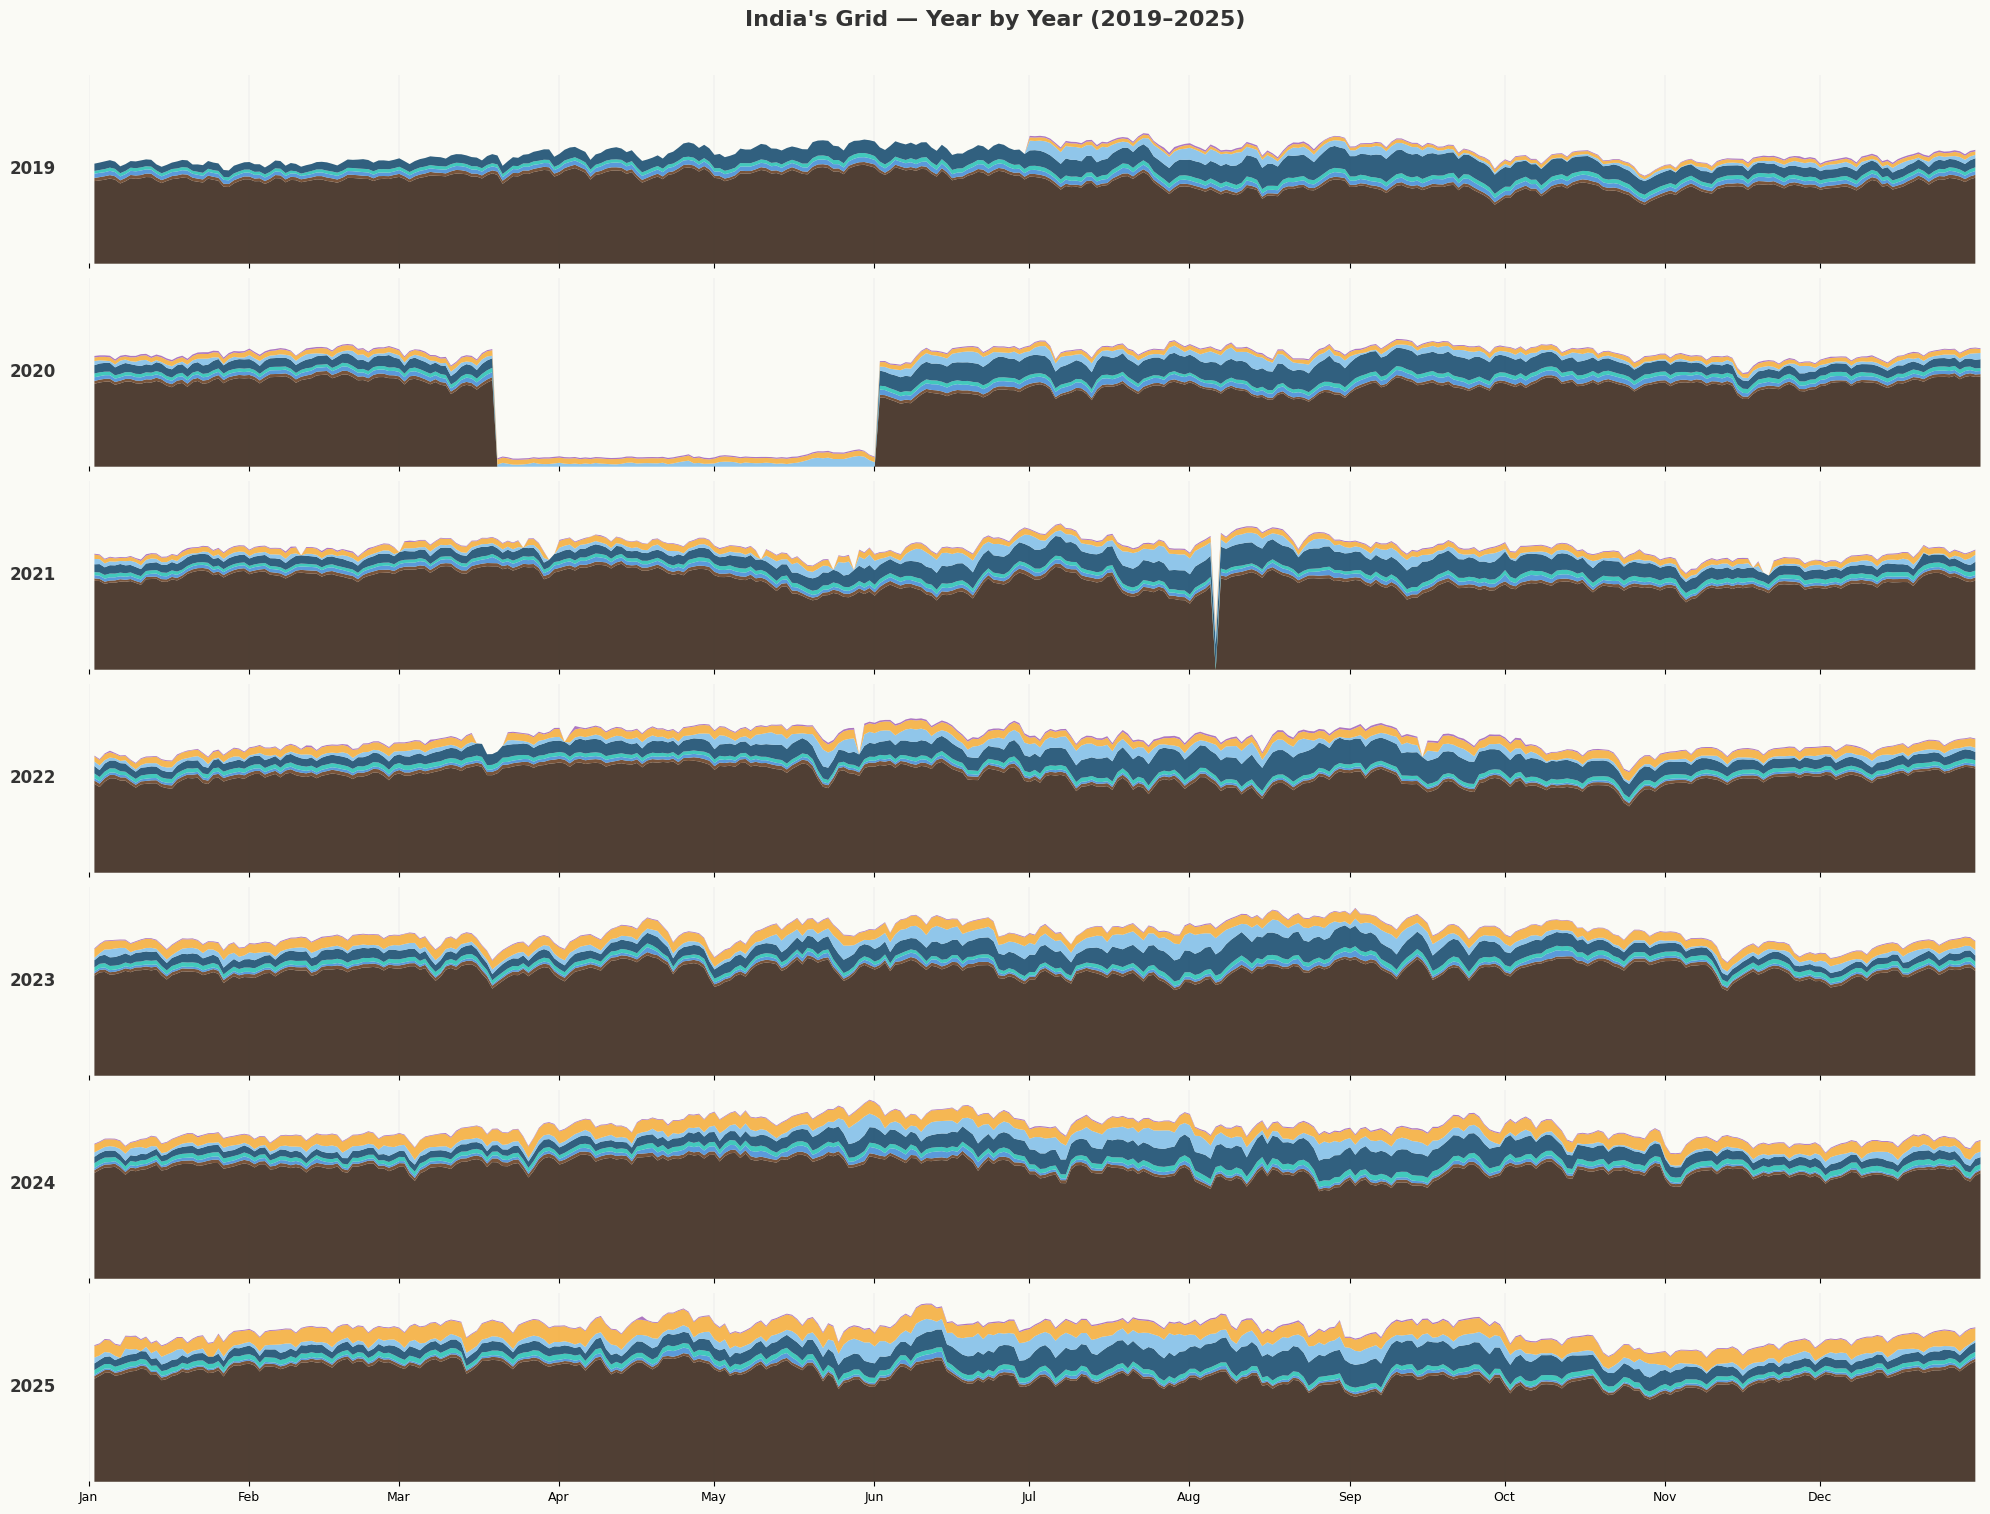

Each strip = one year's daily generation, stacked by fuel.
Look for: coal (dark brown) dominating, solar (gold) growing, COVID 2020 dip.


In [3]:
# Earth & Sky palette
palette = {
    'coal': '#3D2B1F', 'lignite': '#6B4226', 'gas': '#4A90D9',
    'nuclear': '#2EC4B6', 'hydro': '#1B4F72', 'wind': '#85C1E9',
    'solar': '#F5B041', 'other_re': '#A569BD',
}
fuel_cols = ['coal', 'lignite', 'gas', 'nuclear', 'hydro', 'wind', 'solar', 'other_re']

# Years with good fuel coverage
strip_years = list(range(2019, 2026))

fig, axes = plt.subplots(len(strip_years), 1, figsize=(20, 2.2 * len(strip_years)),
                          facecolor=bg_color, sharex=True)

global_max = 0
for yr in strip_years:
    sub = cea[cea['year'] == yr].sort_values('doy').copy()
    for col in fuel_cols:
        sub[col] = sub[col].fillna(0)
    total = sub[fuel_cols].sum(axis=1).max()
    if total > global_max:
        global_max = total

for idx, yr in enumerate(strip_years):
    ax = axes[idx]
    ax.set_facecolor(bg_color)
    
    sub = cea[cea['year'] == yr].sort_values('doy').copy()
    for col in fuel_cols:
        sub[col] = sub[col].fillna(0)
    
    x = sub['doy'].values
    bottom = np.zeros(len(sub))
    
    for fuel in fuel_cols:
        values = sub[fuel].values
        ax.fill_between(x, bottom, bottom + values,
                       color=palette[fuel], alpha=0.9, linewidth=0)
        bottom += values
    
    ax.set_ylim(0, global_max * 1.05)
    ax.set_xlim(1, 366)
    ax.set_ylabel(str(yr), fontsize=12, fontweight='bold', rotation=0, 
                  labelpad=40, va='center', color='#333')
    ax.set_yticks([])
    
    # Light month gridlines
    for ms in month_starts:
        ax.axvline(ms, color='#DDD', linewidth=0.3, zorder=0)
    
    if idx < len(strip_years) - 1:
        ax.set_xticks([])
        ax.spines[:].set_visible(False)
    else:
        ax.set_xticks(month_starts)
        ax.set_xticklabels(month_labels, fontsize=9)
        ax.spines[:].set_visible(False)

fig.suptitle('India\'s Grid — Year by Year (2019–2025)', fontsize=16, 
             fontweight='bold', color='#333', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("Each strip = one year's daily generation, stacked by fuel.")
print("Look for: coal (dark brown) dominating, solar (gold) growing, COVID 2020 dip.")

---
## Form 3: Demand Heatmap + CO2 Overlay

Same heatmap as Form 1, but with a second layer: CO2 emissions as a contour or separate panel below.
Let's try side-by-side: demand on top, CO2 on bottom.

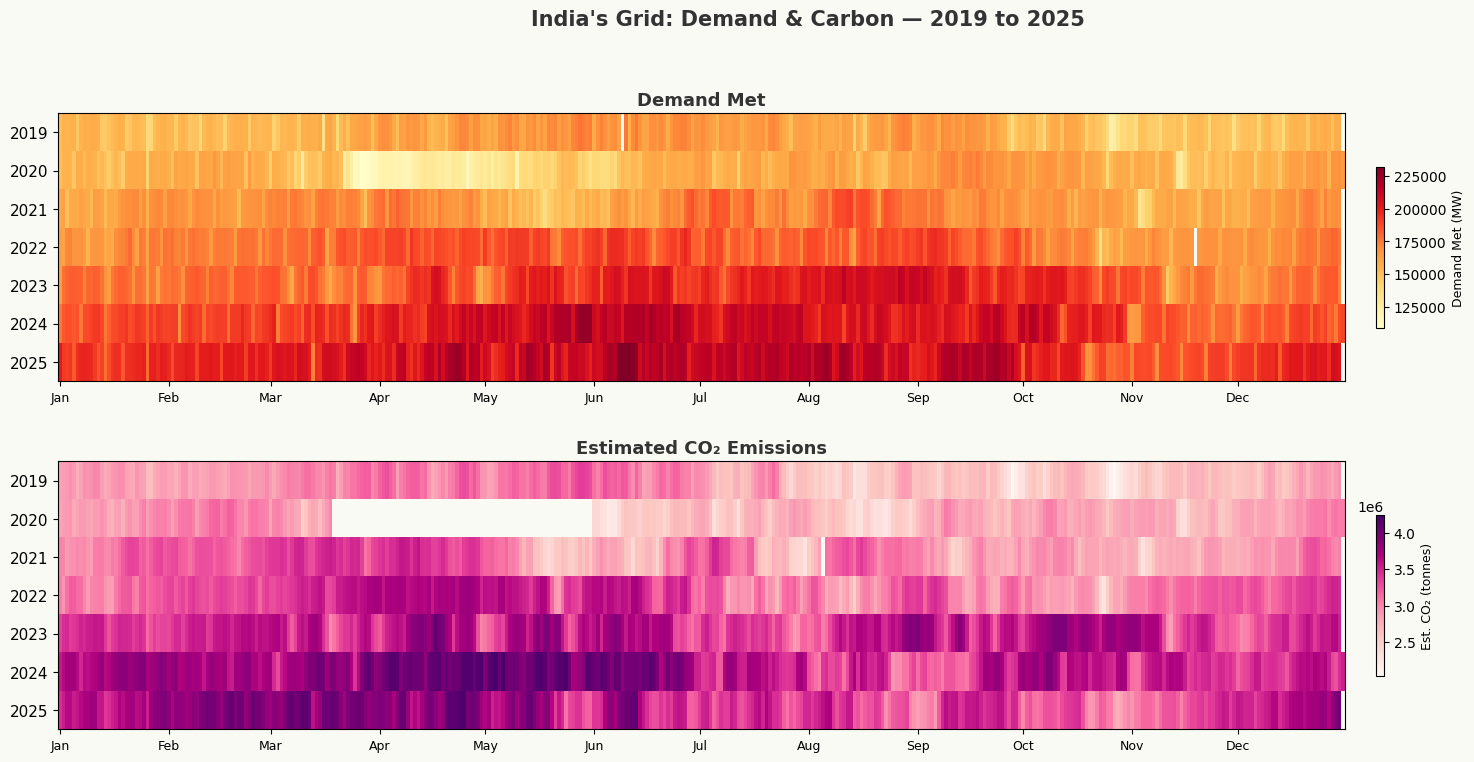

Top = demand (how much electricity India needed). Bottom = CO2 (environmental cost).
Key question: are they decoupling? Is demand growing while CO2 flattens?


In [4]:
# CO2 heatmap — CEA years only (2019–2025 for solid coverage)
co2_years = list(range(2019, 2026))
co2_matrix = np.full((len(co2_years), 366), np.nan)

for i, yr in enumerate(co2_years):
    sub = cea[(cea['year'] == yr) & (cea['co2_est'] > 0)][['doy', 'co2_est']]
    for _, row in sub.iterrows():
        doy = int(row['doy']) - 1
        if doy < 366:
            co2_matrix[i, doy] = row['co2_est']

# Also build demand matrix for matching years (from POSOCO)
demand_matrix_match = np.full((len(co2_years), 366), np.nan)
for i, yr in enumerate(co2_years):
    sub = posoco[posoco['year'] == yr][['doy', 'India: DemandMet']].dropna()
    for _, row in sub.iterrows():
        doy = int(row['doy']) - 1
        if doy < 366:
            demand_matrix_match[i, doy] = row['India: DemandMet']

# ── Two-panel: Demand on top, CO2 on bottom ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 8), facecolor=bg_color,
                                 gridspec_kw={'hspace': 0.3})

for ax in (ax1, ax2):
    ax.set_facecolor(bg_color)

# Top: demand
im1 = ax1.imshow(demand_matrix_match, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax1.set_yticks(range(len(co2_years)))
ax1.set_yticklabels(co2_years, fontsize=11)
ax1.set_xticks(month_starts)
ax1.set_xticklabels(month_labels, fontsize=9)
cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.6, pad=0.02)
cbar1.set_label('Demand Met (MW)', fontsize=9)
ax1.set_title('Demand Met', fontsize=13, fontweight='bold', color='#333')

# Bottom: CO2
im2 = ax2.imshow(co2_matrix, aspect='auto', cmap='RdPu', interpolation='nearest')
ax2.set_yticks(range(len(co2_years)))
ax2.set_yticklabels(co2_years, fontsize=11)
ax2.set_xticks(month_starts)
ax2.set_xticklabels(month_labels, fontsize=9)
cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.6, pad=0.02)
cbar2.set_label('Est. CO₂ (tonnes)', fontsize=9)
ax2.set_title('Estimated CO₂ Emissions', fontsize=13, fontweight='bold', color='#333')

fig.suptitle('India\'s Grid: Demand & Carbon — 2019 to 2025', fontsize=15, 
             fontweight='bold', color='#333', y=1.01)
plt.tight_layout()
plt.show()

print("Top = demand (how much electricity India needed). Bottom = CO2 (environmental cost).")
print("Key question: are they decoupling? Is demand growing while CO2 flattens?")

---
## Form 4: Carbon Intensity Heatmap (single panel)

Instead of two panels, one panel: **CO2 per unit of demand** (emissions intensity).
This is the "how dirty is each unit of electricity" metric — and it should be improving.
If it works, one clean heatmap tells the whole story.

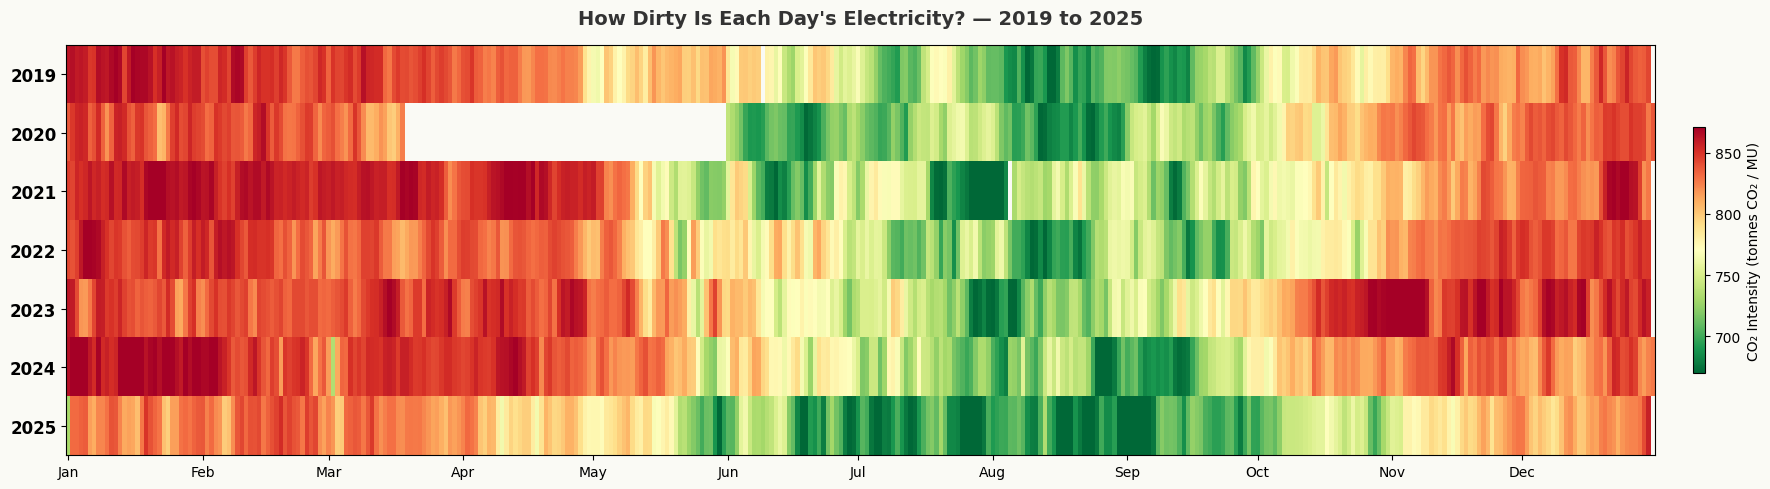

Green = cleaner days. Red = dirtier days.
Look for: monsoon green bands, overall shift toward green in recent years, COVID 2020 pattern.


In [5]:
# Merge CEA CO2 with POSOCO demand for matching days
cea_sub = cea[['date', 'doy', 'year', 'co2_est', 'total', 'coal']].copy()
posoco_sub = posoco[['date', 'India: DemandMet', 'India: EnergyMet']].copy()

merged = cea_sub.merge(posoco_sub, on='date', how='inner')
merged['intensity'] = merged['co2_est'] / merged['India: EnergyMet']  # CO2 per MU of energy

# Build intensity matrix
intensity_years = list(range(2019, 2026))
intensity_matrix = np.full((len(intensity_years), 366), np.nan)

for i, yr in enumerate(intensity_years):
    sub = merged[(merged['year'] == yr) & (merged['intensity'] > 0) & (merged['intensity'].notna())]
    for _, row in sub.iterrows():
        doy = int(row['doy']) - 1
        if doy < 366:
            intensity_matrix[i, doy] = row['intensity']

fig, ax = plt.subplots(figsize=(20, 5), facecolor=bg_color)
ax.set_facecolor(bg_color)

# Use reversed RdYlGn: green = low intensity (clean), red = high intensity (dirty)
im = ax.imshow(intensity_matrix, aspect='auto', cmap='RdYlGn_r', interpolation='nearest',
               vmin=np.nanpercentile(intensity_matrix, 2),
               vmax=np.nanpercentile(intensity_matrix, 98))

ax.set_yticks(range(len(intensity_years)))
ax.set_yticklabels(intensity_years, fontsize=12, fontweight='bold')
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('CO₂ Intensity (tonnes CO₂ / MU)', fontsize=10)

ax.set_title('How Dirty Is Each Day\'s Electricity? — 2019 to 2025', 
             fontsize=14, fontweight='bold', color='#333', pad=15)
plt.tight_layout()
plt.show()

print("Green = cleaner days. Red = dirtier days.")
print("Look for: monsoon green bands, overall shift toward green in recent years, COVID 2020 pattern.")

---
## Form 5: Ridge Plot — Demand Curves Stacked by Year

Each year's daily demand as a filled curve, offset vertically. Like a Joy Division album cover but with data. This form is very poster-friendly.

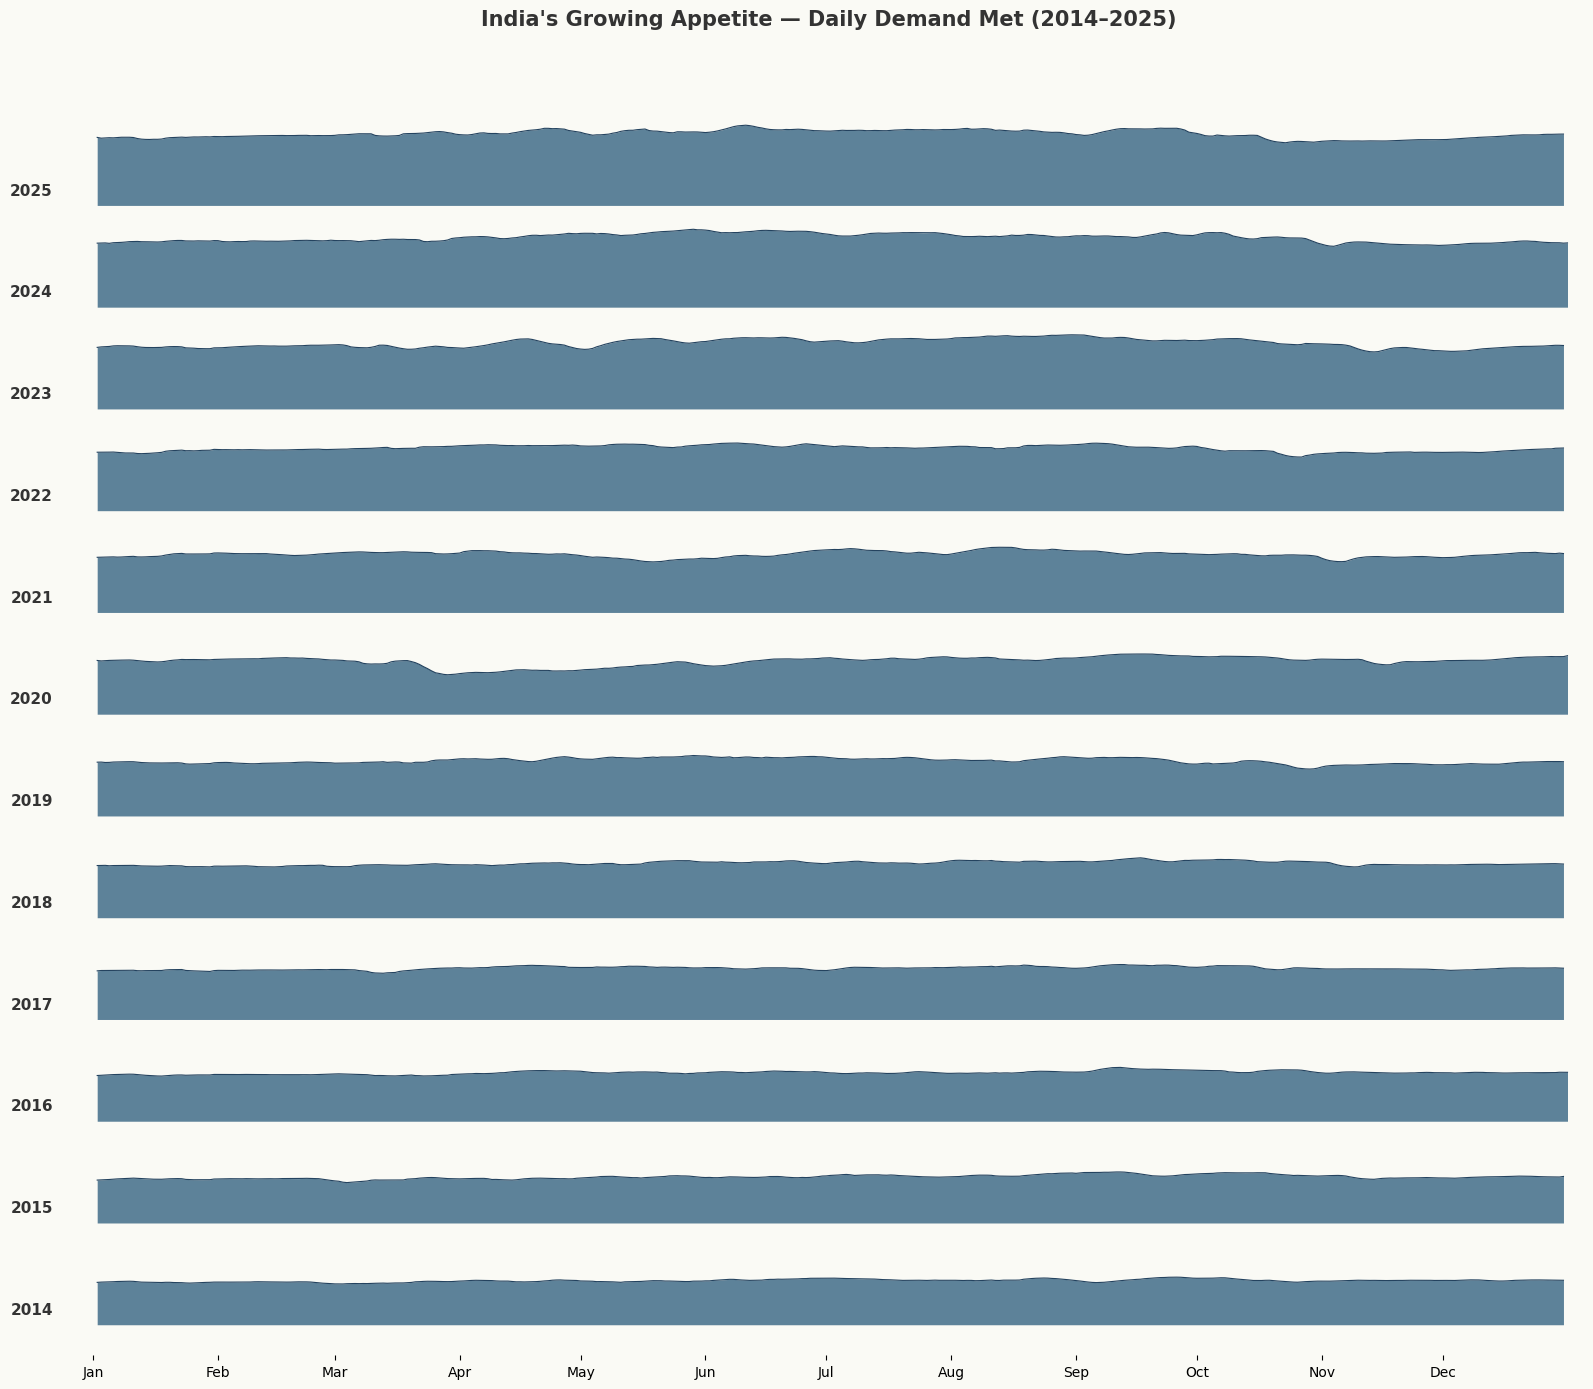

Each ridge = one year's demand curve (7-day smoothed).
The ridges get taller and wider as India's grid grows.


In [6]:
# Ridge plot — demand met by year
ridge_years = list(range(2014, 2026))  # 2013 has gaps early

fig, ax = plt.subplots(figsize=(16, 14), facecolor=bg_color)
ax.set_facecolor(bg_color)

# Normalize all demand to global max for consistent scaling
all_demand = posoco[posoco['year'].isin(ridge_years)]['India: DemandMet'].dropna()
global_max_demand = all_demand.max()

offset_step = 1.0  # vertical offset between years
smooth_window = 7   # 7-day rolling average for smoother curves

for idx, yr in enumerate(ridge_years):
    sub = posoco[posoco['year'] == yr][['doy', 'India: DemandMet']].dropna().sort_values('doy')
    
    x = sub['doy'].values
    y = sub['India: DemandMet'].values / global_max_demand  # normalize to 0–1
    
    # Smooth
    y_smooth = pd.Series(y).rolling(smooth_window, center=True, min_periods=1).mean().values
    
    y_offset = idx * offset_step
    
    # Fill under curve
    ax.fill_between(x, y_offset, y_offset + y_smooth * 0.8,
                   color='#1B4F72', alpha=0.7, linewidth=0)
    # Outline
    ax.plot(x, y_offset + y_smooth * 0.8, color='#0D2F4F', linewidth=0.8, alpha=0.9)
    
    # Year label
    ax.text(-10, y_offset + 0.15, str(yr), fontsize=11, fontweight='bold',
           ha='right', va='center', color='#333')

# Month labels at bottom
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=10)

ax.set_xlim(-5, 370)
ax.set_ylim(-0.3, len(ridge_years) * offset_step + 0.5)
ax.set_yticks([])
ax.spines[:].set_visible(False)
ax.set_title('India\'s Growing Appetite — Daily Demand Met (2014–2025)', 
             fontsize=15, fontweight='bold', color='#333', pad=20)

plt.tight_layout()
plt.show()

print("Each ridge = one year's demand curve (7-day smoothed).")
print("The ridges get taller and wider as India's grid grows.")

---
## Form 6: Ridge Plot with CO2 Color

Same ridge form, but color each day's fill by its carbon intensity.
Green = clean day, red = dirty day. The question: does it get too busy?

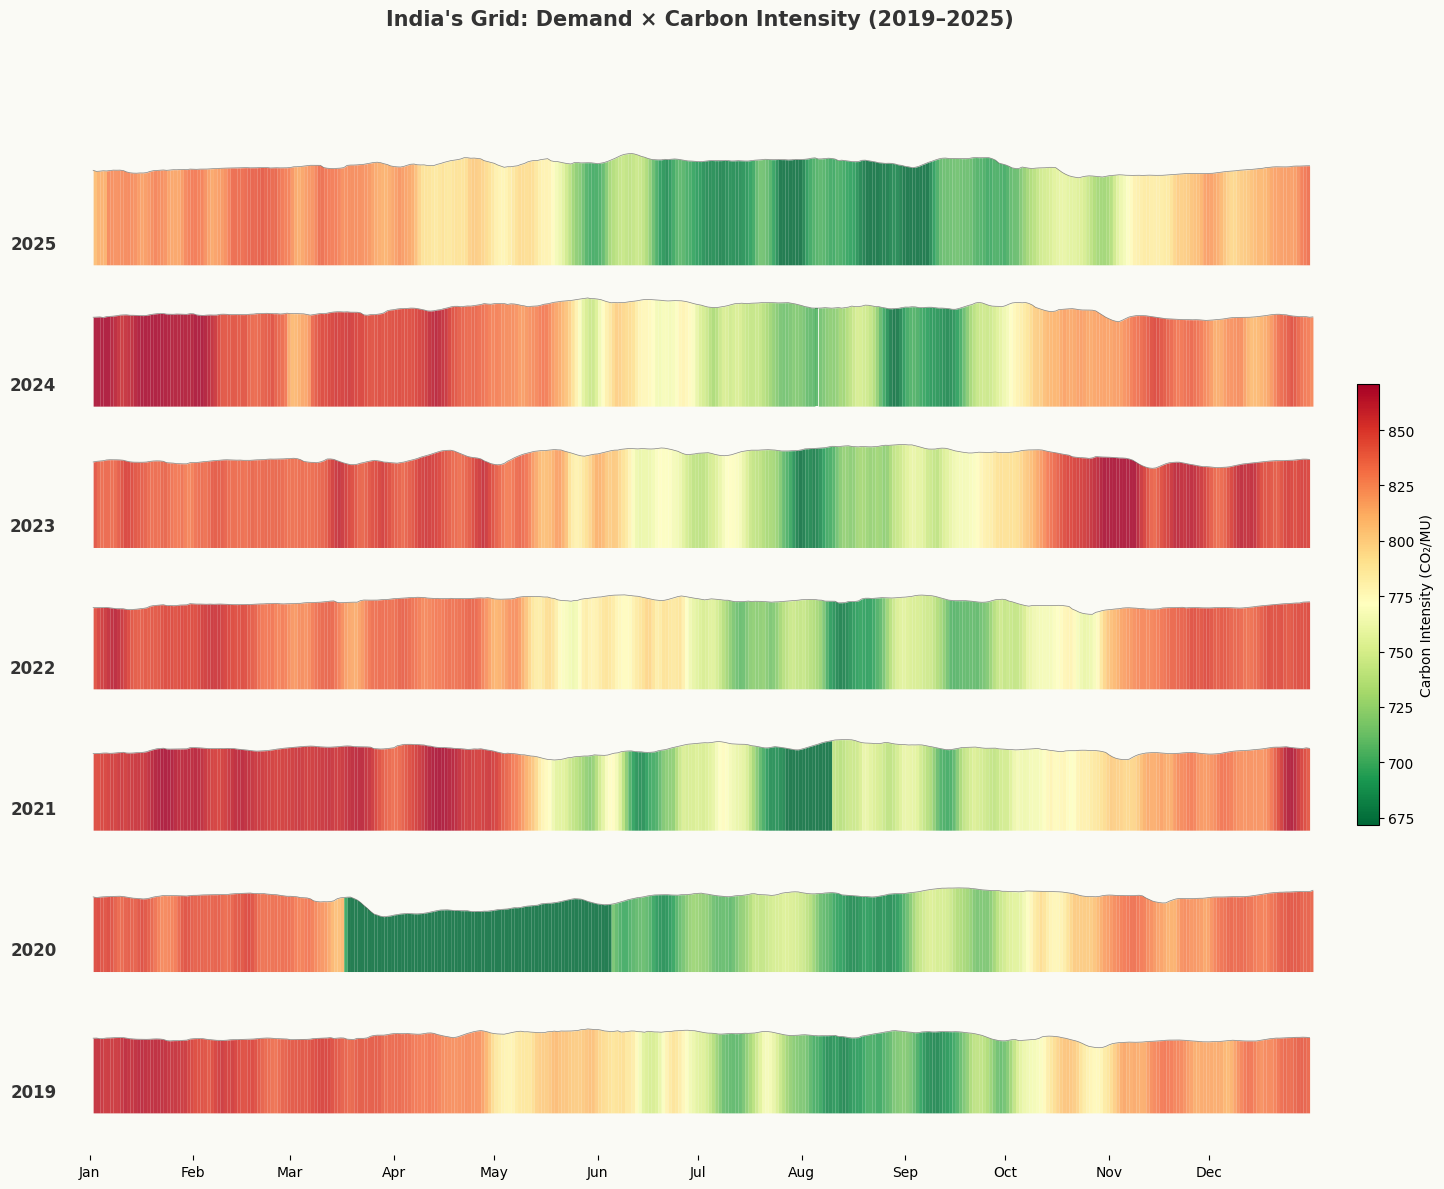

Shape = demand. Color = how dirty that electricity was.
Green ridges = clean days (monsoon). Red ridges = fossil-heavy days.
Is it too busy? Or does the color add a readable second layer?


In [7]:
# Ridge plot with carbon intensity coloring
ridge_co2_years = list(range(2019, 2026))  # years with CO2 data

fig, ax = plt.subplots(figsize=(16, 12), facecolor=bg_color)
ax.set_facecolor(bg_color)

# Get global demand max for these years
all_demand_co2 = posoco[posoco['year'].isin(ridge_co2_years)]['India: DemandMet'].dropna()
gmax = all_demand_co2.max()

# Get global intensity range for consistent color scale
valid_intensity = merged[(merged['intensity'] > 0) & (merged['intensity'].notna())]['intensity']
int_min, int_max = valid_intensity.quantile(0.02), valid_intensity.quantile(0.98)
cmap = plt.cm.RdYlGn_r  # red = high intensity (dirty), green = low
norm = mcolors.Normalize(vmin=int_min, vmax=int_max)

offset_step = 1.0
smooth_window = 7

for idx, yr in enumerate(ridge_co2_years):
    # Get demand
    sub_d = posoco[posoco['year'] == yr][['doy', 'India: DemandMet']].dropna().sort_values('doy')
    # Get intensity
    sub_i = merged[merged['year'] == yr][['doy', 'intensity']].dropna().sort_values('doy')
    
    # Merge on doy
    sub = sub_d.merge(sub_i, on='doy', how='inner')
    
    x = sub['doy'].values
    y = sub['India: DemandMet'].values / gmax
    intensity = sub['intensity'].values
    
    # Smooth both
    y_smooth = pd.Series(y).rolling(smooth_window, center=True, min_periods=1).mean().values
    int_smooth = pd.Series(intensity).rolling(smooth_window, center=True, min_periods=1).mean().values
    
    y_offset = idx * offset_step
    
    # Fill using thin vertical bars colored by intensity
    for j in range(len(x) - 1):
        color = cmap(norm(int_smooth[j]))
        ax.fill_between(x[j:j+2], y_offset, y_offset + y_smooth[j:j+2] * 0.8,
                       color=color, alpha=0.85, linewidth=0)
    
    # Outline
    ax.plot(x, y_offset + y_smooth * 0.8, color='#333', linewidth=0.5, alpha=0.6)
    
    # Year label
    ax.text(-10, y_offset + 0.15, str(yr), fontsize=12, fontweight='bold',
           ha='right', va='center', color='#333')

# Month labels
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=10)

ax.set_xlim(-5, 370)
ax.set_ylim(-0.3, len(ridge_co2_years) * offset_step + 0.5)
ax.set_yticks([])
ax.spines[:].set_visible(False)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label('Carbon Intensity (CO₂/MU)', fontsize=10)

ax.set_title('India\'s Grid: Demand × Carbon Intensity (2019–2025)',
             fontsize=15, fontweight='bold', color='#333', pad=20)

plt.tight_layout()
plt.show()

print("Shape = demand. Color = how dirty that electricity was.")
print("Green ridges = clean days (monsoon). Red ridges = fossil-heavy days.")
print("Is it too busy? Or does the color add a readable second layer?")

---
## Form 7: The Horizon Chart — Demand as Terrain, CO2 as Atmosphere

Inspired by horizon graphs — fold the demand curve into color bands so multiple years compress into less vertical space. More abstract, more art-like.

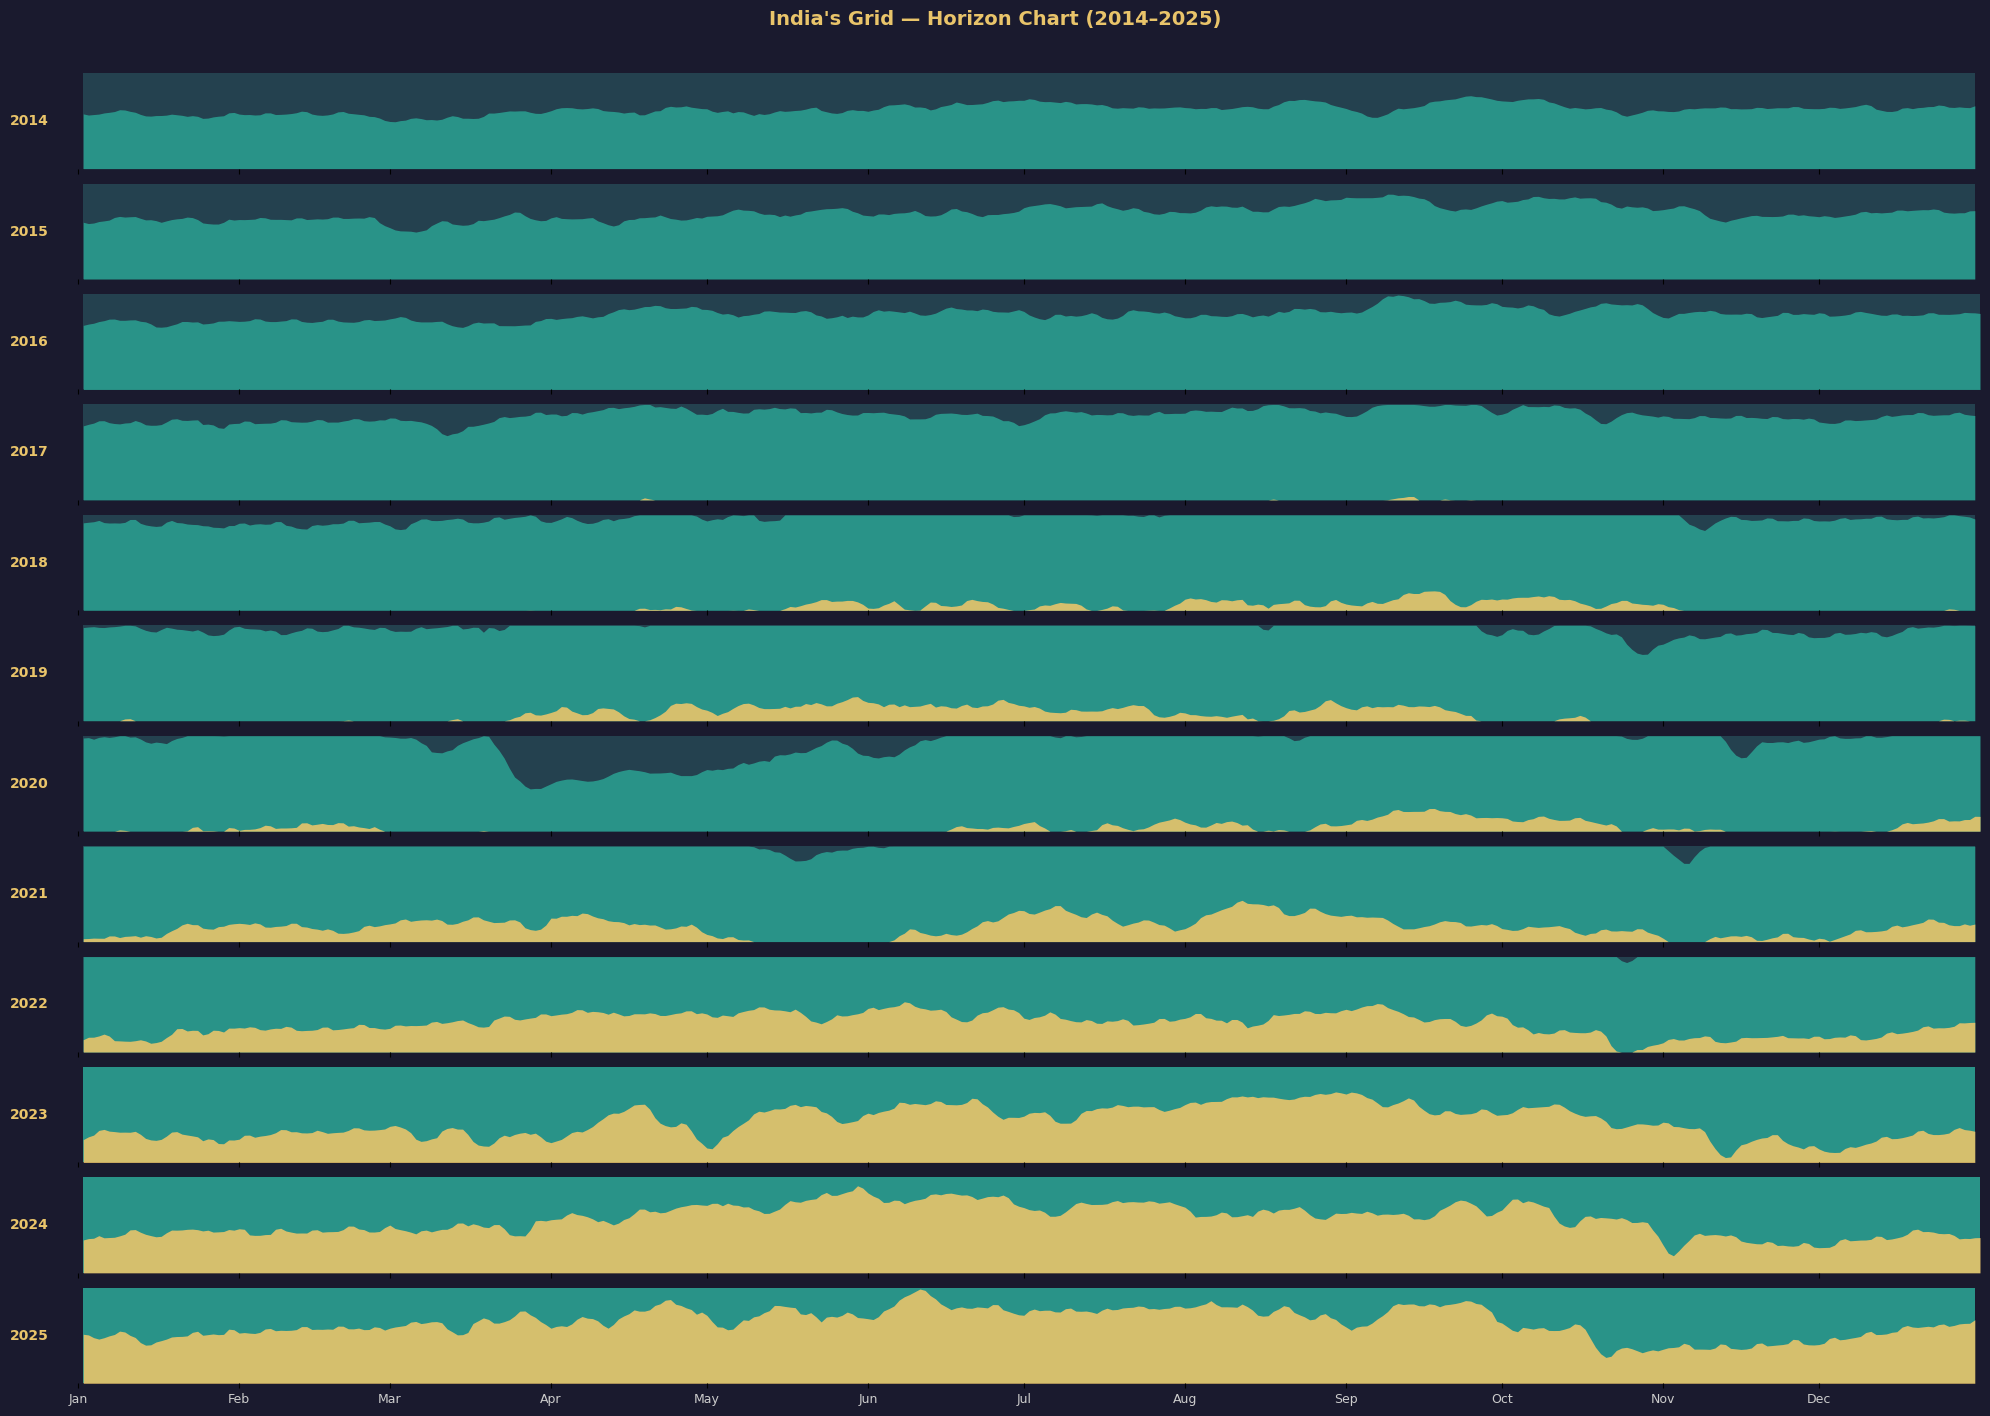

Folded demand into 3 color bands — darker = base load, brighter = peaks.
This compresses vertical space while keeping daily resolution.


In [8]:
# Horizon chart — each year compressed into bands
horizon_years = list(range(2014, 2026))
n_bands = 3  # fold into 3 bands

fig, axes = plt.subplots(len(horizon_years), 1, figsize=(20, 1.2 * len(horizon_years)),
                          facecolor='#1a1a2e', sharex=True)

# Color bands from light to saturated
band_colors = ['#264653', '#2a9d8f', '#e9c46a']  # dark teal → teal → gold

all_demand_h = posoco[posoco['year'].isin(horizon_years)]['India: DemandMet'].dropna()
gmax_h = all_demand_h.max()
band_height = gmax_h / n_bands

for idx, yr in enumerate(horizon_years):
    ax = axes[idx]
    ax.set_facecolor('#1a1a2e')
    
    sub = posoco[posoco['year'] == yr][['doy', 'India: DemandMet']].dropna().sort_values('doy')
    x = sub['doy'].values
    y = sub['India: DemandMet'].values
    
    # Smooth
    y_smooth = pd.Series(y).rolling(5, center=True, min_periods=1).mean().values
    
    # Draw bands (folded)
    for band in range(n_bands):
        lower = band * band_height
        band_vals = np.clip(y_smooth - lower, 0, band_height)
        ax.fill_between(x, 0, band_vals, color=band_colors[band], alpha=0.9, linewidth=0)
    
    ax.set_ylim(0, band_height)
    ax.set_xlim(1, 366)
    ax.set_yticks([])
    ax.set_ylabel(str(yr), fontsize=10, fontweight='bold', rotation=0,
                  labelpad=35, va='center', color='#e9c46a')
    ax.spines[:].set_visible(False)
    
    if idx == len(horizon_years) - 1:
        ax.set_xticks(month_starts)
        ax.set_xticklabels(month_labels, fontsize=9, color='#ccc')
    else:
        ax.set_xticks([])

fig.suptitle('India\'s Grid — Horizon Chart (2014–2025)', fontsize=14,
             fontweight='bold', color='#e9c46a', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("Folded demand into 3 color bands — darker = base load, brighter = peaks.")
print("This compresses vertical space while keeping daily resolution.")

---
## What are we looking at?

| Form | Data | Static poster potential | Risk |
|------|------|----------------------|------|
| **1. Demand Heatmap** | POSOCO demand, 13 years | Clean, dense, readable | Maybe too "dashboard" |
| **2. Stacked Year Strips** | CEA fuel mix, 7 years | Rich, shows fuel evolution | Could be busy |
| **3. Demand + CO2 dual panel** | Both sources | Complete story | Two panels = busy |
| **4. Carbon Intensity heatmap** | Merged CO2/demand | Single panel, clear narrative | Only 7 years |
| **5. Ridge Plot (mono)** | POSOCO demand, 12 years | Very poster-friendly, Joy Division feel | One-dimensional |
| **6. Ridge + CO2 color** | Both sources | Shape + color = two stories | Could be noisy |
| **7. Horizon Chart** | POSOCO demand, 12 years | Abstract, compressed, artful | Less intuitive |

Run the notebook and let's see which ones sing.